# Trabajo final:

**Enlace de obtención del dataset:** https://www.openml.org/search?type=data&sort=runs&id=45279&status=active

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ajustes de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


Explicación de cada variable:


- `pkSeqID`	            Row Identifier
- `sbytes`	            Source-to-destination byte count
- `Stime` 	            Record start time
- `dbytes`	            Destination-to-source byte count
- `flgs`	            Flow state flags seen in trans- actions
- `rate`  	            Total packets per second in transaction
- `flgs number`	        Numerical representation of feature flags
- `srate`	            Source-to-destination packets per second
- `Proto`	            Textual representation of transaction protocols present in network flow
- `drate`	            Destination-to-source packets per second
- `proto_number`	    Numerical representation of feature proto
- `TnBPSrcIP`	        Total Number of bytes per source IP
- `saddr`               Source IP address
- `TnBPDstIP`	        Total Number of bytes per Destination IP
- `sport`	            Source port number
- `TnP_PSrcIP`	        Total Number of packets per source IP
- `daddr`	            Destination IP address
- `TnP_PDstIP`	        Total Number of packets per Destination IP
- `dport`	            Destination port number
- `TnP_PerProto`	    Total Number of packets per protocol
- `pkts`	            Total count of packets in transaction
- `TnP_Per_Dport`	    Total Number of packets per dport
- `bytes`	            Total number of bytes in transaction
- `AR_P_Proto_P_SrcIP`	Average rate per protocol per Source IP. (calculated by pkts/dur)
- `state`	            Transaction state
- `AR_P_Proto_P_DstIP`	Average rate per protocol per Destination IP
- `state_number`    	Numerical representation of feature state
- `ltime`           	Record last time
- `N_IN_Conn_P_SrcIP`	Number of inbound connections per source IP
- `seq`	                Argus sequence number
- `N_IN_Conn_P_DstIP`	Number of inbound connections per destination IP
- `dur`	                Record total duration
- `AR_P_Proto_P_Sport`	Average rate per protocol per sport
- `mean`            	Average duration of aggregated records
- `AR_P_Proto_P_Dport`	Average rate per protocol per dport
- `stddev`          	Standard deviation of aggregated records
- `Pkts_P_State_P_Protocol_P_DestIP`	Number of packets grouped by state of flows and protocols per destination IP
- `sum`            	    Total duration of aggregated records
- `Pkts_P_State_P_Protocol_P_SrcIP` 	Number of packets grouped by state of flows and protocols per source IP
- `min`             	Minimum duration of aggregated records
- `attack`          	Class label: 0 for Normal traffic, 1 for Attack Traffic
- `max`             	Maximum duration of aggregated records
- `category`        	Traffic category
- `spkts`           	Source-to-destination packet count
- `subcategory`     	Traffic subcategory
- `dpkts`           	Destination-to-source packet count

## Preprocesado:

In [3]:
dtypes = {
    'stime': 'float32', 
    'flgs': 'category', 
    'flgs_number': 'UInt8', 
    'proto': 'category', 
    'proto_number': 'UInt8', 
    'saddr': 'category', 
    'sport': 'Int32', 
    'daddr': 'category', 
    'dport': 'Int32', 
    'pkts': 'UInt32', 
    'bytes': 'UInt32', 
    'state': 'category', 
    'state_number': 'UInt8', 
    'ltime': 'float32', 
    'seq': 'UInt32', 
    'dur': 'float32', 
    'mean': 'float32', 
    'stddev': 'float32', 
    'sum': 'float32', 
    'min': 'float32', 
    'max': 'float32', 
    'spkts': 'UInt16', 
    'dpkts': 'UInt16', 
    'sbytes': 'UInt32', 
    'dbytes': 'UInt32', 
    'rate': 'float32', 
    'srate': 'float32', 
    'drate': 'float32', 
    'TnBPSrcIP': 'UInt32', 
    'TnBPDstIP': 'UInt32', 
    'TnP_PSrcIP': 'UInt32', 
    'TnP_PDstIP': 'UInt32', 
    'TnP_PerProto': 'UInt32', 
    'TnP_Per_Dport': 'UInt32', 
    'AR_P_Proto_P_SrcIP': 'float32', 
    'AR_P_Proto_P_DstIP': 'float32', 
    'N_IN_Conn_P_DstIP': 'UInt8', 
    'N_IN_Conn_P_SrcIP': 'UInt8', 
    'AR_P_Proto_P_Sport': 'float32', 
    'AR_P_Proto_P_Dport': 'float32', 
    'Pkts_P_State_P_Protocol_P_DestIP': 'UInt32', 
    'Pkts_P_State_P_Protocol_P_SrcIP': 'UInt32', 
    'device': 'category', 
    'attack': 'category', 
    'category': 'category', 
    'subcategory': 'category'
    }

In [ ]:
df = pd.read_csv("datos_ciber.csv", index_col='pkSeqID', dtype=dtypes)

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 3668522 entries, 1000001 to 3668522
Data columns (total 46 columns):
 #   Column                            Dtype   
---  ------                            -----   
 0   stime                             float32 
 1   flgs                              category
 2   flgs_number                       UInt8   
 3   proto                             category
 4   proto_number                      UInt8   
 5   saddr                             category
 6   sport                             Int32   
 7   daddr                             category
 8   dport                             Int32   
 9   pkts                              UInt32  
 10  bytes                             UInt32  
 11  state                             category
 12  state_number                      UInt8   
 13  ltime                             float32 
 14  seq                               UInt32  
 15  dur                               float32 
 16  mean                        

In [ ]:
df.sort_values(by=['dpkts'])

,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,pkts,bytes,state,state_number,ltime,seq,dur,mean,stddev,sum,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,device,attack,category,subcategory
pkSeqID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80,8,480,INT,4,1.528085e+09,120567,25.001644,3.565624,0.023105,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
2344698,1.528096e+09,e s,2,tcp,1,192.168.100.148,25582,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169158,12.835121,2.149763,1.525840,6.449290,0.000000,3.386419,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389536,0.389536,100,100,0.389556,0.389536,500,500,external,Malicious,DDoS,TCP
2344699,1.528096e+09,e s,2,tcp,1,192.168.100.148,25583,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169159,12.835121,2.149763,1.525840,6.449288,0.000000,3.386418,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389536,0.389536,100,100,0.389556,0.389536,500,500,external,Malicious,DDoS,TCP
2344700,1.528096e+09,e s,2,tcp,1,192.168.100.148,25584,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169160,12.835121,2.149762,1.525839,6.449287,0.000000,3.386417,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389536,0.389536,100,100,0.389556,0.389536,500,500,external,Malicious,DDoS,TCP
2344701,1.528096e+09,e s,2,tcp,1,192.168.100.148,25585,192.168.100.3,80,5,770,REQ,3,1.528096e+09,169161,12.835121,2.149762,1.525839,6.449287,0.000000,3.386417,5,0,770,0,0.311645,0.311645,0.000000,77000,77000,500,500,500,500,0.389533,0.389533,100,100,0.389556,0.389533,500,500,external,Malicious,DDoS,TCP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3576926,1.526344e+09,e,1,udp,3,192.168.100.46,3456,192.168.100.5,80,59452,59114121,CON,2,1.526346e+09,2,1685.706909,4.947584,0.231615,1662.388062,0.710969,4.999863,29726,29726,30347258,28766863,35.267696,17.633553,17.633553,220390664,220390784,225519,225521,200009,244425,26.667999,26.667999,7,6,35.557301,26.667999,112544,112544,external,Benign,Normal,Normal
3577165,1.526350e+09,e &,7,tcp,1,192.168.100.55,8080,192.168.100.3,80,69595,69797982,CON,2,1.526352e+09,1,1745.653564,4.966639,0.008544,1728.390259,4.950418,4.995234,34798,34797,35616240,34181742,39.867016,19.933508,19.932936,69797982,92682875,69595,121862,140717,220979,39.867599,19.450800,7,1,39.867599,22.258200,102714,69595,external,Benign,Normal,Normal
3577168,1.526350e+09,e,1,udp,3,192.168.100.46,3456,192.168.100.5,80,69600,69187620,CON,2,1.526352e+09,4,1745.758057,4.967142,0.007519,1728.565430,4.950445,4.997839,34800,34800,35020980,34166640,39.867496,19.933460,19.933460,134442585,134442585,139201,139201,123687,220979,29.901100,29.901100,3,3,39.868099,29.901100,69600,69600,external,Benign,Normal,Normal


### Tratamiento de datos faltantes:

In [ ]:
# Contamos la cantidad de datos faltanes por variable 
df.isna().sum()

stime                               0
flgs                                0
flgs_number                         0
proto                               0
proto_number                        0
saddr                               0
sport                               0
daddr                               0
dport                               0
pkts                                0
bytes                               0
state                               0
state_number                        0
ltime                               0
seq                                 0
dur                                 0
mean                                0
stddev                              0
sum                                 0
min                                 0
max                                 0
spkts                               0
dpkts                               0
sbytes                              0
dbytes                              0
rate                                0
srate       

Vemos que no ninguna de las variables cuenta con datos faltanes.

### Tratamiento de outliers:

In [ ]:
# Solo columnas numéricas
df_num = df.select_dtypes(include=np.number)

# Media y std vectorizados
mean = df_num.mean()
std = df_num.std()

outliers_z = ((df_num - mean).abs() > 3 * std)
outliers_ordenados_z = outliers_z.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) {'-'*5}")
print(outliers_ordenados_z)

----- CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) -----
flgs_number                         128953
N_IN_Conn_P_DstIP                   121130
stime                                91638
ltime                                91638
dport                                28081
AR_P_Proto_P_DstIP                   25683
N_IN_Conn_P_SrcIP                    17061
AR_P_Proto_P_SrcIP                   14248
rate                                  7178
AR_P_Proto_P_Sport                    6932
AR_P_Proto_P_Dport                    6712
state_number                          2586
drate                                 2005
dur                                   1539
srate                                  451
TnP_PerProto                           355
Pkts_P_State_P_Protocol_P_DestIP       141
TnP_PSrcIP                             105
TnBPSrcIP                               63
TnP_Per_Dport                           51
TnP_PDstIP                              49
Pkts_P_State_P_Protocol_P_SrcIP    

In [9]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))
outliers_ordenados_iqr = outliers_iqr.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (USANDO IQR) {'-'*5}")
print(outliers_ordenados_iqr)

----- CANTIDAD DE OUTLIERS POR COLUMNA (USANDO IQR) -----
dpkts                               860828
dbytes                              860828
N_IN_Conn_P_DstIP                   798222
state_number                        784141
spkts                               443504
rate                                343654
AR_P_Proto_P_SrcIP                  294145
AR_P_Proto_P_Dport                  279903
srate                               274902
drate                               270243
AR_P_Proto_P_Sport                  261815
AR_P_Proto_P_DstIP                  256209
TnP_PDstIP                          197258
TnP_PSrcIP                          166345
pkts                                140466
flgs_number                         129769
N_IN_Conn_P_SrcIP                   110683
dport                                94947
TnP_PerProto                         91754
stime                                91638
ltime                                91638
TnP_Per_Dport                        91

In [10]:
outliers_ambos = outliers_z & outliers_iqr
outliers_ordenados_ambos = outliers_ambos.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (DETECTADOS POR AMBOS MÉTODOS) {'-'*5}")
print(outliers_ordenados_ambos)

----- CANTIDAD DE OUTLIERS POR COLUMNA (DETECTADOS POR AMBOS MÉTODOS) -----
flgs_number                         128953
N_IN_Conn_P_DstIP                   121130
stime                                91638
ltime                                91638
dport                                28081
AR_P_Proto_P_DstIP                   25683
N_IN_Conn_P_SrcIP                    17061
AR_P_Proto_P_SrcIP                   14248
rate                                  7178
AR_P_Proto_P_Sport                    6932
AR_P_Proto_P_Dport                    6712
state_number                          2586
drate                                 2005
dur                                   1539
srate                                  451
TnP_PerProto                           355
Pkts_P_State_P_Protocol_P_DestIP       141
TnP_PSrcIP                             105
TnBPSrcIP                               63
TnP_Per_Dport                           51
TnP_PDstIP                              49
Pkts_P_State_P_Protoc

#### Eliminación de los outliers fuera de rango:

In [ ]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='category').columns

# Plotear variables numéricas con boxplot para detectar outliers
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4*len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].set_ylabel('Valor')

plt.tight_layout()
plt.show()

# Plotear variables categóricas con countplot
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 3*len(categorical_cols)))
if len(categorical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Conteo - {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### Winsorización de los outliers correspondientes:

In [ ]:
from scipy.stats.mstats import winsorize

# Definir las columnas a winsorizar y sus límites de percentil

def winsorize_df(df: pd.DataFrame, columns: list[str], lower=0.1, upper=0.1):
    df_out = df.copy()
    
    for col in columns:
        if col in df_out.columns:
            # Convertir a float (evita problemas con pandas dtypes raros)
            x = df_out[col].astype('float64')
            
            # Aplicar winsorización
            x_w = winsorize(x, limits=(lower, upper))
            
            # Guardar de vuelta (como float)
            df_out[col] = x_w.astype('float64')
    
    return df_out

cols_winsor = [
    'stime', 'ltime', 'dport', 'rate', 'srate', 'drate',
    'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP',
    'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport'
]

df_winsorized = winsorize_df(df, cols_winsor, lower=0.01, upper=0.01)

In [25]:
df_winsorized

,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,pkts,bytes,state,state_number,ltime,seq,dur,mean,stddev,sum,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,device,attack,category,subcategory
pkSeqID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120567,25.001644,3.565624,0.023105,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000002,1.528085e+09,e,1,udp,3,192.168.100.148,37154,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120568,25.001644,3.565624,0.023096,14.262495,3.539352,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000003,1.528085e+09,e,1,udp,3,192.168.100.148,37155,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120569,25.001644,3.565624,0.023096,14.262495,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000004,1.528085e+09,e,1,udp,3,192.168.100.148,37156,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120570,25.001644,3.565624,0.023059,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000005,1.528085e+09,e,1,udp,3,192.168.100.148,37157,192.168.100.6,80.0,8,480,INT,4,1.528085e+09,120571,25.001644,3.565624,0.023096,14.262495,3.539353,3.601969,8,0,480,0,0.279982,0.279982,0.000000,48000,48000,800,800,800,800,0.319943,0.319943,100.0,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3668518,1.528099e+09,e,1,tcp,1,192.168.100.150,35064,192.168.100.3,80.0,6,434,RST,1,1.528099e+09,81,0.013165,0.013165,0.000000,0.013165,0.013165,0.013165,3,3,228,206,379.794922,5.977894,0.158919,79240,79240,471,471,475,471,9.889330,9.889330,19.0,19,455.753998,9.889330,30,30,external,Malicious,Theft,Keylogging
3668519,1.528099e+09,e,1,tcp,1,192.168.100.150,35066,192.168.100.3,80.0,6,434,RST,1,1.528099e+09,82,0.000574,0.000574,0.000000,0.000574,0.000574,0.000574,3,3,228,206,1153.402466,5.977894,0.158919,79240,79240,471,471,475,471,9.889330,9.889330,19.0,19,6775.990234,9.889330,30,30,external,Malicious,Theft,Keylogging
3668520,1.528099e+09,e,1,tcp,1,192.168.100.150,35070,192.168.100.3,80.0,31,5472,FIN,6,1.528099e+09,84,2.874302,2.874302,0.000000,2.874302,2.874302,2.874302,14,17,1802,3670,10.437317,4.522837,0.158919,79240,79240,471,471,475,471,9.889330,9.889330,19.0,19,10.785200,9.889330,441,441,external,Malicious,Theft,Keylogging


In [27]:
# Solo columnas numéricas
df_num = df_winsorized.select_dtypes(include=np.number)

# Media y std vectorizados
mean = df_num.mean()
std = df_num.std()

outliers_z = ((df_num - mean).abs() > 3 * std)
outliers_ordenados_z = outliers_z.sum().sort_values(ascending=False)

print(f"{'-'*5} CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) {'-'*5}")
print(outliers_ordenados_z)

----- CANTIDAD DE OUTLIERS POR COLUMNA (USANDO Z-SCORE) -----
flgs_number                         128953
N_IN_Conn_P_DstIP                   128312
srate                               117224
stime                                91559
ltime                                91559
drate                                89257
dport                                56064
AR_P_Proto_P_Dport                   49996
AR_P_Proto_P_Sport                   49219
rate                                 47494
AR_P_Proto_P_SrcIP                   46849
AR_P_Proto_P_DstIP                   45551
N_IN_Conn_P_SrcIP                    17061
state_number                          2586
dur                                   1539
TnP_PerProto                           355
Pkts_P_State_P_Protocol_P_DestIP       141
TnP_PSrcIP                             105
TnBPSrcIP                               63
TnP_Per_Dport                           51
TnP_PDstIP                              49
Pkts_P_State_P_Protocol_P_SrcIP    

### Transformación:

### Análisis exploratorio:

#### Análisis de la correlación y colinealidad entre variables:

In [5]:
df.describe(include="all").round(2)

,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,pkts,bytes,state,state_number,ltime,seq,dur,mean,stddev,sum,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,device,attack,category,subcategory
count,3.668522e+06,3668522,3668522.00,3668522,3668522.0,3668522,3668522.00,3668522,3668522.00,3668522.00,3668522.00,3668522,3668522.00,3.668522e+06,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3.668522e+06,3.668522e+06,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522.00,3668522,3668522,3668522,3668522
unique,NaN,9,NaN,5,NaN,21,NaN,84,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,2,5,8
top,NaN,e,NaN,udp,NaN,192.168.100.147,NaN,192.168.100.3,NaN,NaN,NaN,INT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,external,Malicious,DDoS,UDP
freq,NaN,2293445,NaN,1996437,NaN,950966,NaN,2375733,NaN,NaN,NaN,1996208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3654753,3668045,1926624,1981230
mean,1.528050e+09,NaN,1.49,NaN,2.1,NaN,32937.53,NaN,392.62,7.73,869.05,NaN,3.13,1.528050e+09,121320.42,20.33,2.23,0.89,7.72,1.02,3.02,7.31,0.41,766.39,102.66,244.94,2.96,0.45,5.101615e+04,5.684558e+04,619.71,687.20,753.57,736.91,332.74,285.18,92.45,82.54,456.49,538.52,642.29,586.00,NaN,NaN,NaN,NaN
std,2.581498e+05,NaN,0.87,NaN,1.0,NaN,19116.33,NaN,3321.93,115.59,112266.67,NaN,1.19,2.581507e+05,75794.28,21.49,1.52,0.80,7.62,1.48,1.86,77.26,49.65,71929.80,49449.03,7919.94,724.54,60.29,4.428125e+05,4.152998e+05,584.21,584.93,1434.39,652.71,8466.03,4096.94,18.18,24.40,14329.17,15698.24,453.34,433.26,NaN,NaN,NaN,NaN
min,1.526344e+09,NaN,1.00,NaN,1.0,NaN,-1.00,NaN,-1.00,1.00,60.00,NaN,1.00,1.526344e+09,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,42.00,0.00,0.00,0.00,0.00,6.000000e+01,6.000000e+01,1.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,NaN,NaN,NaN,NaN
25%,1.528085e+09,NaN,1.00,NaN,1.0,NaN,16280.00,NaN,80.00,5.00,420.00,NaN,3.00,1.528085e+09,54876.00,12.56,0.18,0.03,0.34,0.00,0.28,5.00,0.00,420.00,0.00,0.19,0.16,0.00,3.201000e+04,3.896000e+04,350.00,438.00,502.00,500.00,0.24,0.24,100.00,69.00,0.23,0.25,324.00,294.00,NaN,NaN,NaN,NaN
50%,1.528096e+09,NaN,1.00,NaN,3.0,NaN,33329.00,NaN,80.00,7.00,600.00,NaN,4.00,1.528096e+09,117769.00,15.51,2.69,0.79,8.27,0.00,4.01,6.00,0.00,600.00,0.00,0.31,0.28,0.00,4.752000e+04,5.400000e+04,566.00,616.00,700.00,700.00,0.39,0.40,100.00,100.00,0.38,0.39,600.00,500.00,NaN,NaN,NaN,NaN
75%,1.528099e+09,NaN,2.00,NaN,3.0,NaN,49640.00,NaN,80.00,9.00,770.00,NaN,4.00,1.528099e+09,184930.00,27.10,3.57,1.75,11.71,2.15,4.29,8.00,0.00,770.00,0.00,0.49,0.49,0.00,6.600000e+04,7.546000e+04,800.00,836.00,924.00,920.00,0.57,0.58,100.00,100.00,0.57,0.58,828.00,800.00,NaN,NaN,NaN,NaN


In [6]:
df.head(20)

,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,pkts,bytes,state,state_number,ltime,seq,dur,mean,stddev,sum,min,max,spkts,dpkts,sbytes,dbytes,rate,srate,drate,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,device,attack,category,subcategory
pkSeqID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1000001,1.528085e+09,e,1,udp,3,192.168.100.148,37153,192.168.100.6,80,8,480,INT,4,1.528085e+09,120567,25.001644,3.565624,0.023105,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000002,1.528085e+09,e,1,udp,3,192.168.100.148,37154,192.168.100.6,80,8,480,INT,4,1.528085e+09,120568,25.001644,3.565624,0.023096,14.262495,3.539352,3.601970,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000003,1.528085e+09,e,1,udp,3,192.168.100.148,37155,192.168.100.6,80,8,480,INT,4,1.528085e+09,120569,25.001644,3.565624,0.023096,14.262495,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000004,1.528085e+09,e,1,udp,3,192.168.100.148,37156,192.168.100.6,80,8,480,INT,4,1.528085e+09,120570,25.001644,3.565624,0.023059,14.262497,3.539353,3.601970,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000005,1.528085e+09,e,1,udp,3,192.168.100.148,37157,192.168.100.6,80,8,480,INT,4,1.528085e+09,120571,25.001644,3.565624,0.023096,14.262495,3.539353,3.601969,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000006,1.528085e+09,e,1,udp,3,192.168.100.148,37158,192.168.100.6,80,8,480,INT,4,1.528085e+09,120572,25.001644,3.565624,0.023096,14.262495,3.539353,3.601969,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000007,1.528085e+09,e,1,udp,3,192.168.100.148,37159,192.168.100.6,80,8,480,INT,4,1.528085e+09,120573,25.001642,3.565623,0.023096,14.262493,3.539352,3.601969,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000008,1.528085e+09,e,1,udp,3,192.168.100.148,37160,192.168.100.6,80,8,480,INT,4,1.528085e+09,120574,25.001644,3.565624,0.023096,14.262495,3.539353,3.601969,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP
1000009,1.528085e+09,e,1,udp,3,192.168.100.148,37161,192.168.100.6,80,8,480,INT,4,1.528085e+09,120575,25.001642,3.568303,0.022240,14.273211,3.539353,3.601969,8,0,480,0,0.279982,0.279982,0.0,48000,48000,800,800,800,800,0.319943,0.319943,100,100,0.319979,0.319943,800,800,external,Malicious,DoS,UDP


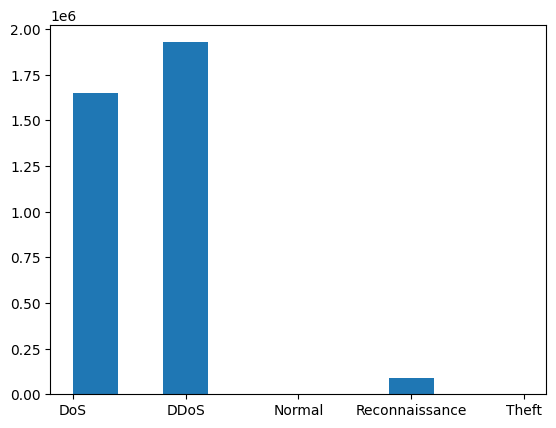

In [ ]:
plt.hist(df["category"])
plt.show()

In [ ]:
df["category"].unique()

<StringArray>
['DoS', 'DDoS', 'Normal', 'Reconnaissance', 'Theft']
Length: 5, dtype: str

In [ ]:
total_observaciones = len(df)

for category, count in df["category"].value_counts().items():
    print(f"{category}: {count}")

print()

for category, count in df["category"].value_counts().items():
    print(f"{category}: {round(count/total_observaciones, 5)*100}%.")


DDoS: 1926624
DoS: 1650260
Reconnaissance: 91082
Normal: 477
Theft: 79

DDoS: 52.518%.
DoS: 44.984%.
Reconnaissance: 2.483%.
Normal: 0.013%.
Theft: 0.002%.


In [ ]:
columnas = [i for i in df.columns]

print(columnas)
print(len(columnas))

['pkSeqID', 'stime', 'flgs', 'flgs_number', 'proto', 'proto_number', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'state_number', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto', 'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP', 'Pkts_P_State_P_Protocol_P_SrcIP', 'device', 'attack', 'category', 'subcategory']
47


In [ ]:
contador = 0

for i in df.columns:
    contador += 1

print(f"Contamos con {contador} variables.")

Contamos con 47 variables.


#### Visualización de las variables:

#### Principales métricas:

### División del dataset en train y test:

### Selección de variables:

## Modelo Autoencoder+MLP:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

### Autoencoder:

#### Definición del autoencoder:

In [ ]:
# 1. Definir el Autoencoder
encoder = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(46,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),   # Cuello de botella
])

decoder = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(32,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(46, activation='linear'), 
])

# Autoencoder completo
autoencoder = keras.Sequential([encoder, decoder])

#### Compilación del autoencoder:

In [ ]:
# 2. Compilar
autoencoder.compile(optimizer='adam', loss='mse')

#### Entrenamiento del autoencoder:

In [ ]:
autoencoder.fit(x_train, x_train, epochs=10, batch_size=32, 
                validation_data=(x_test, x_test))

In [ ]:

# 4. Usar el encoder para extraer features
encoded_data = encoder.predict(x_test)
print(encoded_data.shape)  # (10000, 32)

### Perceptrón multicapa:

#### Definición del perceptrón:

#### Compilación del perceptrón:

#### Entrenamiento del perceptrón:

### Modelo final: